# Neural Nets: the Universal Approximator

The Universal Approximation Theorem states that a neural network with a single hidden layer containing a finite but sufficiently large number of neurons can approximate any continuous function to an arbitrary level of accuracy. In this lab, you will empirically test this theorem by building and training your first neural networks to fit four distinct functional shapes. [Here is your Gem](https://gemini.google.com/gem/1nuFGec2FCxedvhE2LHDtjVSqX-DEIqOD?usp=sharing).

`~/bin/submit -c=SD312 -p=lab06nns 06UniversalApprox.ipynb`

**Setup**

First, refresh your certificates so we can get around ITSD's nonsense. Run `setup python-certs`.

Then, create a new mamba virtual environment set up to run neural-nets on GPUs [as described on the resources page](../../resources/resources/#using-pytorch-and-gpus). We'll be using a library called PyTorch.

**The Datasets**

We will begin by creating a baseline feature set $x$. We generate 200 equidistant points across the interval $[-2, 2]$ and store them in a 1D NumPy array called `xs`.

To test the flexibility of our neural network, we define four different target variables ($y$) based on `xs`:
- `yCos`: A cosine function ($2 \cdot \cos(2x)$)
- `yAbs`: An absolute value function ($|x|$)
- `yParab`: A downward-opening parabola ($-0.5x^2 + x - 2$)
- `yStep`: A step function (values of $-2$ for $x < 0$ and $2$ for $x \ge 0$)

Run the following blocks to generate these values and visualize them using Plotly. Review the plot to understand the different "shapes" the network will attempt to learn. Observe how they would probably need very different features to fit them!

In [2]:
import numpy as np
import plotly.graph_objects as go

In [3]:
xs=np.linspace(-2,2,num=200)

yCos=2*np.cos(2*xs)
yAbs=np.abs(xs)
yParab=-.5*xs*xs+xs-2
yStep=[]
for x in xs:
    if x<0:
        yStep.append(-2)
    else:
        yStep.append(2)
yStep=np.array(yStep)

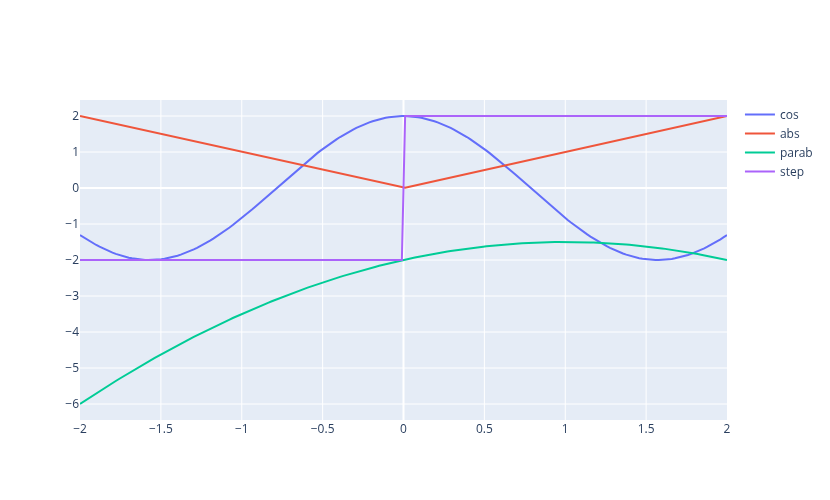

In [4]:
p1=go.Scatter(x=xs,y=yCos,name='cos')
p2=go.Scatter(x=xs,y=yAbs,name='abs')
p3=go.Scatter(x=xs,y=yParab,name='parab')
p4=go.Scatter(x=xs,y=yStep,name='step')
layout=go.Layout(height=500)
fig=go.Figure(data=[p1,p2,p3,p4],layout=layout)
fig.show()

If we wanted to do linear regression on all of these, we would need to build some smart features, each hand designed for each function.  Let's just use a neural net instead.  Let's fit the cosine function first.

Before feeding data into a neural network, we must convert our NumPy arrays into **PyTorch Tensors**. Tensors are the fundamental data structure in PyTorch, similar to NumPy arrays but capable of running on GPUs and tracking gradients for optimization.

**Why `.reshape()`?**
PyTorch expects input data and target labels to be formatted as 2D matrices. In these matrices:

* Each **row** represents a single data sample (observation).
* Each **column** represents a specific feature.

Even though our input is a single list of numbers, PyTorch requires it to be a "column vector" of shape (200,1) rather than a flat 1D array of shape (200,).

The following function, `create_tensors`, handles the reshaping and the conversion to `torch.float32`, which is the standard precision for neural network calculations.

Run the code below to prepare the tensors for our first task: fitting the cosine function ($yCos$).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
def create_tensors(x,y):
    data=torch.tensor(x.reshape(-1,1), dtype=torch.float32)
    targets=torch.tensor(y.reshape(-1,1),dtype=torch.float32)
    return data, targets
data, targets = create_tensors(xs, yCos)
print(f'data shape: {data.shape}, targets shape: {targets.shape}')

<div style="background-color: #fff3cd; border-left: 6px solid #ffc107; padding: 15px; color: #856404;">
  <strong>🟡 AI Policy: YELLOW</strong> <br>
  Generative AI is allowed, with limitations.
</div>

OK, now let's build a Neural Net.  Use [the class notes as a guide](../../notes/nns/), and create a net that takes in a data point of 1 feature, and consists of a single hidden layer of 3 neurons, followed by a Sigmoid activation function, followed by an output layer which outputs 1 value, with no activation.

Create an instance of your object, and then print it (`model = YourModelName()`, `print(model)`).  What do you see?

Again using the class notes as a guide, train your network using mean squared error on this data. Occasionally print out the loss value so you can see if it decreases.

Now that you have trained your network, you must evaluate how well it approximates the target function. You will create a plot to compare the ground truth (`yCos`) with your model's predictions.

To plot the predictions, they must be converted from a PyTorch tensor back into a format compatible with visualization tools:

* Pass your input `data` tensor through your model.
* Call `.detach()` on the output tensor. PyTorch tensors track "gradients" (slopes) to allow for optimization during training. Visualization libraries cannot process tensors while they are still attached to this computational graph.
* The model outputs a (200,1) matrix. Use `.flatten()` to convert this into a 1D vector of shape (200,1) to match the dimensions of your `xs` array.

<div style="background-color: #d4edda; border-left: 6px solid #28a745; padding: 15px; color: #155724;">
  <strong>🟢 AI Policy: GREEN</strong> <br>
  Generative AI is allowed/encouraged for this section.
</div>

Generate a single visualization containing two lines, the targets `yCos` and your processed prediction values. Be sure to use a legend so we can tell which is the truth and which is your prediction.

How close are your predictions to the true function?  Despite the fact that your final layer is a linear combination of features, is the prediction nonetheless curved?

You can probably get that pretty close, right?  Now train the same network on the absolute value target (`yAbs`).  How close are the predictions?  Show me a plot again.

Now show me the other two functions (the parabola and step functions).

Which ones are best, and which ones are worse?

<div style="background-color: #fff3cd; border-left: 6px solid #ffc107; padding: 15px; color: #856404;">
  <strong>🟡 AI Policy: YELLOW</strong> <br>
  Generative AI is allowed, with limitations.
</div>

There's a number of changes we can make to our network.
- We can make the hidden layer wider, by redefining the network to have a wider hidden layer. This would allow for more features to be combined.
- We could change the [activation function](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity) (ReLU is especially popular for its speed in calculating the gradient).
- We could add more layers, with activation functions of their own.
- We can train it longer.

Try some things.  How closely can you fit it?  How low can you get the loss to go?

Now for the real trick - we can build a neural net that regresses upon multiple functions at once.  Take the neural net that worked the best on the step function above, and redefine it below so that rather than outputting a single value, it outputs 4.

Neural networks possess the structural flexibility to approximate several independent functions simultaneously within a single architecture. This approach, often called **multi-task learning**, allows the hidden layers to learn a shared set of features that are useful for all target outputs.

In the cell below, modify your most successful model architecture—the one that produced the best results for the above functions—to handle all four functions at once.

* **Select Your Best Architecture**: Use the number of hidden layers and the layer width (number of neurons) that you found most effective in the previous exercise.
* **Modify the Output Layer**: Change the final `nn.Linear` layer. Previously, your output layer was defined to produce a single value. Redefine it so that the `out_features` parameter is set to **4**. There should still not be an activation function.

The below cell creates a tensor `targets` which is 200x4, where each row contains the cos of that data point, the abs of that data point, the parabola's value of that data point, and the step function of that datapoint.

In [ ]:
alltargets=np.zeros((200,4))
alltargets[:,0]=yCos
alltargets[:,1]=yAbs
alltargets[:,2]=yParab
alltargets[:,3]=yStep
targets=torch.tensor(alltargets,dtype=torch.float32)
print(f'targets shape is {targets.shape}')

Train your neural net, fitting your data to this 200 x 4 target.  When an input tensor of shape $(200, 1)$ is passed through this new model, the resulting output tensor should have a shape of $(200, 4)$, representing a prediction for each of the four functions at every point $x$.

<div style="background-color: #d4edda; border-left: 6px solid #28a745; padding: 15px; color: #155724;">
  <strong>🟢 AI Policy: GREEN</strong> <br>
  Generative AI is allowed/encouraged for this section.
</div>

Make a plot showing the actual functions, and your approximations to those functions (maybe as dotted lines to make it readable).  Your graph will have 8 lines on it.